# Testing classifiers and models

In [1]:
#=================== SETUP ===================

import os
import glob
import random
import numpy as np
import tensorflow as tf
import mimetypes

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
print("✅ Setup complete")

2026-03-21 11:54:21.479737: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ GPU memory growth enabled
✅ Setup complete


In [2]:
# =================== PATHS & DATA SOURCES ===================

# בסיס הפרויקט
GDRIVE_PATH = os.path.expanduser('~/RealEyes/gdrive')
BASE_PROJECT_PATH = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'code')

# נתיבי דאטה
CODE_PATH = os.path.join(GDRIVE_PATH, 'code')
DATA_PATH = os.path.join(GDRIVE_PATH, 'data_set')
DATA_SPLIT_PATH = os.path.join(GDRIVE_PATH, 'data_set_split')

# תיקיית שמירה למודלים של SRM / AE
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')
os.makedirs(AE_SAVE_DIR, exist_ok=True)

# נתיב בסיס לפיצול של CustomWar
DATASET_ROOT = DATA_SPLIT_PATH

# ---------------- TRAIN ----------------
train_datasets = {
    'CiFake': './datasets/cifake/train',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Train',
    'CustomWar': os.path.join(DATASET_ROOT, 'train')
}

# ---------------- VALIDATION ----------------
validation_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Validation',
    'CustomWar': os.path.join(DATASET_ROOT, 'val')
}

# ---------------- TEST ----------------
test_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Test',
    'CustomWar': os.path.join(DATASET_ROOT, 'test')
}

print("✅ Paths & data sources ready")
print(f"GDRIVE_PATH:      {GDRIVE_PATH}")
print(f"BASE_PROJECT_PATH:{BASE_PROJECT_PATH}")
print(f"DATA_PATH:        {DATA_PATH}")
print(f"DATA_SPLIT_PATH:  {DATA_SPLIT_PATH}")
print(f"AE_SAVE_DIR:      {AE_SAVE_DIR}")

✅ Paths & data sources ready
GDRIVE_PATH:      /home/sceuser/RealEyes/gdrive
BASE_PROJECT_PATH:/home/sceuser/RealEyes/gdrive/deepfake_image_project/code
DATA_PATH:        /home/sceuser/RealEyes/gdrive/data_set
DATA_SPLIT_PATH:  /home/sceuser/RealEyes/gdrive/data_set_split
AE_SAVE_DIR:      /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae


In [3]:
# =================== HELPER: LOAD DATASET IMAGES ===================

def load_dataset_images(dataset_path, max_images=None):
    """Load image paths and labels from a dataset directory with STRICT label assignment."""
    image_paths = []
    labels = []

    # ONLY these extensions are valid
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

    folders = os.listdir(dataset_path)

    # מיון כדי שהסדר יהיה צפוי (למרות שאנחנו מתקנים את זה למטה)
    folders.sort()

    skipped_count = 0

    for folder in folders:
        path = os.path.join(dataset_path, folder)
        if not os.path.isdir(path):
            continue

        folder_upper = folder.upper()

        if folder_upper == 'FAKE':
            current_label = 1  # תמיד 1 לזיוף
        elif folder_upper == 'REAL':
            current_label = 0  # תמיד 0 לאמיתי
        else:
            print(f"⚠️ Warning: Unknown folder name '{folder}'. Skipping.")
            continue
        # =========================================================

        for i, filename in enumerate(os.listdir(path)):
            if max_images and i >= max_images:
                break

            file_path = os.path.join(path, filename)

            # Check if it's a file
            if not os.path.isfile(file_path):
                continue

            # Check file extension
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                skipped_count += 1
                continue

            # MIME type check
            mime_type, _ = mimetypes.guess_type(file_path)
            if mime_type and mime_type not in {'image/jpeg', 'image/png', 'image/gif', 'image/bmp'}:
                skipped_count += 1
                continue

            image_paths.append(file_path) # list of all the pictures - where does each pic locate
            labels.append(current_label) # list of numbres 0, 1 that match to pictures (real/fake)

    if skipped_count > 0:
        print(f"   ⚠️ Skipped {skipped_count} non-standard files in {dataset_path}")

    print(f"   ✅ Loaded {len(image_paths)} valid images from {dataset_path}")
    return image_paths, np.array(labels)

In [4]:
# =================== FULL DATA LOADING ===================

def load_all_datasets(datasets_dict, purpose_name):
    print(f"\n📦 Processing {purpose_name} Sets (FULL LOADING)...")
    print("=" * 60)

    all_paths = []
    all_labels = []

    for ds_name, ds_path in datasets_dict.items():
        print(f"   📥 Loading {ds_name} (ALL IMAGES)...")
        paths, labels = load_dataset_images(ds_path, max_images=None)
        all_paths.extend(paths)
        all_labels.extend(labels)

    return np.array(all_paths), np.array(all_labels)

print("🏗️ Building FULL Training Set...")
train_image_paths, train_labels = load_all_datasets(train_datasets, "TRAIN")

print("\n🏗️ Building FULL Validation Set...")
validation_image_paths, val_labels = load_all_datasets(validation_datasets, "VALIDATION")

print("\n🏗️ Building FULL Test Set...")
test_image_paths, test_labels = load_all_datasets(test_datasets, "TEST")

🏗️ Building FULL Training Set...

📦 Processing TRAIN Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 100000 valid images from ./datasets/cifake/train
   📥 Loading OpenForensics (ALL IMAGES)...
   ✅ Loaded 140002 valid images from ./datasets/OpenForensicsV1/Dataset/Train
   📥 Loading CustomWar (ALL IMAGES)...
   ✅ Loaded 1941 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/train

🏗️ Building FULL Validation Set...

📦 Processing VALIDATION Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 20000 valid images from ./datasets/cifake/test
   📥 Loading OpenForensics (ALL IMAGES)...
   ✅ Loaded 39428 valid images from ./datasets/OpenForensicsV1/Dataset/Validation
   📥 Loading CustomWar (ALL IMAGES)...
   ✅ Loaded 242 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/val

🏗️ Building FULL Test Set...

📦 Processing TEST Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 20000 valid images from ./datasets/

In [5]:
# =================== DATASET STATISTICS ===================

print("\n" + "=" * 60)
print("📊 FINAL FULL DATASET SUMMARY")
print("=" * 60)
print(f"Train: {len(train_image_paths):,}")
print(f"Val:   {len(validation_image_paths):,}")
print(f"Test:  {len(test_image_paths):,}")
print("=" * 60)

def print_label_stats(name, labels):
    labels = np.array(labels)
    real_count = np.sum(labels == 0)
    fake_count = np.sum(labels == 1)
    print(f"{name}: REAL={real_count:,}, FAKE={fake_count:,}, TOTAL={len(labels):,}")

print_label_stats("TRAIN", train_labels)
print_label_stats("VAL", val_labels)
print_label_stats("TEST", test_labels)


📊 FINAL FULL DATASET SUMMARY
Train: 241,943
Val:   59,670
Test:  31,149
TRAIN: REAL=120,620, FAKE=121,323, TOTAL=241,943
VAL: REAL=29,864, FAKE=29,806, TOTAL=59,670
TEST: REAL=15,491, FAKE=15,658, TOTAL=31,149


In [6]:
##6# =================== SHARED PREPROCESSING ===================

IMG_SIZE_RGB = (224, 224)
IMG_SIZE_SRM = (256, 256)

BATCH_SIZE_RGB = 8
BATCH_SIZE_SRM = 32
BATCH_SIZE_HYBRID = 4

AUTOTUNE = tf.data.AUTOTUNE

def decode_rgb_image(path, label, img_size=(224, 224)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.float32)

def decode_rgb_image_normalized(path, label, img_size=(256, 256)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

def create_rgb_dataset(image_paths, labels, batch_size=BATCH_SIZE_RGB, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: decode_rgb_image(p, y, IMG_SIZE_RGB), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print("✅ Shared preprocessing ready")

✅ Shared preprocessing ready


# SRM Model

In [7]:
# =================== SRM FILTERS ===================

import numpy as np

# -------------------------------
# 5x5 SRM-style filters
# -------------------------------
filters_5x5 = [
    # Filter 1: Laplacian-High Boost
    [[0, 0, -1, 0, 0],
     [0, -1, 2, -1, 0],
     [-1, 2, 4, 2, -1],
     [0, -1, 2, -1, 0],
     [0, 0, -1, 0, 0]],

    # Filter 2: Edge & Noise Enhancer
    [[-1, 2, -2, 2, -1],
     [2, -6, 8, -6, 2],
     [-2, 8, -12, 8, -2],
     [2, -6, 8, -6, 2],
     [-1, 2, -2, 2, -1]],

    # Filter 3: Diagonal Residuals
    [[2, -1, 0, -1, 2],
     [-1, -2, 3, -2, -1],
     [0, 3, 0, 3, 0],
     [-1, -2, 3, -2, -1],
     [2, -1, 0, -1, 2]],

    # Filter 4: Vertical Edge
    [[0, 0, 0, 0, 0],
     [1, -2, 1, -2, 1],
     [0, 0, 0, 0, 0],
     [-1, 2, -1, 2, -1],
     [0, 0, 0, 0, 0]],

    # Filter 5: High-Frequency / Noise Pattern
    [[1, -4, 6, -4, 1],
     [-4, 16, -24, 16, -4],
     [6, -24, 36, -24, 6],
     [-4, 16, -24, 16, -4],
     [1, -4, 6, -4, 1]],
]

# -------------------------------
# 3x3 filters to be padded into 5x5
# -------------------------------
filters_3x3_raw = [
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]],  # Basic Laplacian

    [[-1, 2, -1],
     [2, -4, 2],
     [-1, 2, -1]],  # Residual

    [[-1, -1, -1],
     [-1, 8, -1],
     [-1, -1, -1]]  # Point detection
]

def pad_3x3_to_5x5(kernels_3x3):
    padded_kernels = []
    for k in kernels_3x3:
        padded = np.pad(k, ((1, 1), (1, 1)), mode='constant', constant_values=0)
        padded_kernels.append(padded)
    return padded_kernels

filters_3x3_padded = pad_3x3_to_5x5(filters_3x3_raw)

# -------------------------------
# Final filter bank: 8 filters total
# -------------------------------
all_filters = np.array(filters_5x5 + filters_3x3_padded, dtype=np.float32)

print(f"✅ SRM filters ready: {len(all_filters)} filters, each of size 5x5")
print("all_filters shape:", all_filters.shape)

✅ SRM filters ready: 8 filters, each of size 5x5
all_filters shape: (8, 5, 5)


In [8]:
# =================== SRM FILTER FUNCTION ===================

import tensorflow as tf

# all_filters shape: (8, 5, 5)
# TF kernel shape should be: (5, 5, 1, 8)
srm_filters_tf = tf.constant(
    np.transpose(all_filters[:, :, :, np.newaxis], (1, 2, 3, 0)),
    dtype=tf.float32
)

def apply_srm_filters_tf(image):
    """
    Apply SRM filters (8 filters + tanh) to an RGB image.

    Args:
        image: Tensor of shape (H, W, 3) or (B, H, W, 3)

    Returns:
        SRM feature maps of shape:
        - (256, 256, 24) for single image
        - (B, 256, 256, 24) for batch
    """
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
        squeeze = True
    else:
        squeeze = False

    image = tf.image.resize(image, [256, 256])
    image = tf.cast(image, tf.float32)

    channels = tf.split(image, num_or_size_splits=3, axis=-1)

    feature_maps = []
    for channel in channels:
        fm = tf.nn.conv2d(channel, srm_filters_tf, strides=1, padding='SAME')
        fm = (tf.math.tanh(fm) + 1.0) / 2.0
        feature_maps.append(fm)

    result = tf.concat(feature_maps, axis=-1)

    if squeeze:
        result = result[0]

    return result

print("✅ apply_srm_filters_tf() ready")
print("   Input: RGB image (H, W, 3) or (B, H, W, 3)")
print("   Output: SRM feature maps (256, 256, 24) or (B, 256, 256, 24)")
print("   Kernel tensor shape:", srm_filters_tf.shape)

✅ apply_srm_filters_tf() ready
   Input: RGB image (H, W, 3) or (B, H, W, 3)
   Output: SRM feature maps (256, 256, 24) or (B, 256, 256, 24)
   Kernel tensor shape: (5, 5, 1, 8)


I0000 00:00:1774094078.999872  426443 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [9]:
##9# =================== SRM DATASET PIPELINE ===================

def srm_augment(srm_features, label):
    srm_features = tf.image.random_flip_left_right(srm_features)
    srm_features = tf.image.random_flip_up_down(srm_features)
    srm_features = tf.image.random_brightness(srm_features, max_delta=0.05)
    srm_features = tf.clip_by_value(srm_features, 0.0, 1.0)
    return srm_features, label

def create_srm_dataset(image_paths, labels, batch_size=BATCH_SIZE_SRM, shuffle=False, augment=False):
    def process_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [256, 256])
        img = tf.cast(img, tf.float32) / 255.0

        srm_features = apply_srm_filters_tf(img)
        srm_features = tf.ensure_shape(srm_features, [256, 256, 24])

        return srm_features, tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)

    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(srm_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)

    return ds

print("✅ SRM dataset pipeline ready")

✅ SRM dataset pipeline ready


In [10]:
# =================== PREPARE FULL SRM DATASETS ===================

print("📦 Creating FULL SRM datasets...")
print("=" * 60)

train_srm_dataset = create_srm_dataset(
    train_image_paths,
    train_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=True,
    augment=True
)

val_srm_dataset = create_srm_dataset(
    validation_image_paths,
    val_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=False
)

test_srm_dataset = create_srm_dataset(
    test_image_paths,
    test_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=False
)

print(f"✅ Train SRM images: {len(train_image_paths):,}")
print(f"✅ Val SRM images:   {len(validation_image_paths):,}")
print(f"✅ Test SRM images:  {len(test_image_paths):,}")

📦 Creating FULL SRM datasets...


2026-03-21 11:54:44.503573: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/py

✅ Train SRM images: 241,943
✅ Val SRM images:   59,670
✅ Test SRM images:  31,149


In [11]:
# =================== SRM SANITY CHECK ===================

for x_batch, y_batch in train_srm_dataset.take(1):
    print("SRM batch shape:", x_batch.shape)
    print("Labels shape:", y_batch.shape)
    print("Min:", tf.reduce_min(x_batch).numpy(), "Max:", tf.reduce_max(x_batch).numpy())

SRM batch shape: (32, 256, 256, 24)
Labels shape: (32,)
Min: 0.0 Max: 1.0


2026-03-21 11:54:47.705662: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
# =================== CLEAR GPU MEMORY ===================

import tensorflow as tf
import gc
import os

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

gc.collect()
tf.keras.backend.clear_session()

print("✅ Cleared previous session")


print("📊 GPU MEMORY STATUS:")
os.system("nvidia-smi")

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Cleared previous session
📊 GPU MEMORY STATUS:
Sat Mar 21 11:54:48 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   52C    P0              28W /  70W |    368MiB / 15360MiB |      0%      Default |
|         

0

In [13]:
# =================== AUTOENCODER / ENCODER ===================

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
import tensorflow as tf

print("🔨 Building SRM Autoencoder...")

# --------------------------------------------------
# Autoencoder input
# --------------------------------------------------
input_img = layers.Input(shape=(256, 256, 24), name="srm_input")

# ======================
# Encoder
# ======================
x = layers.Conv2D(32, (3, 3), padding="same", name="enc_conv1")(input_img)
x = layers.BatchNormalization(name="enc_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act1")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)   # 128x128

x = layers.Conv2D(64, (3, 3), padding="same", name="enc_conv2")(x)
x = layers.BatchNormalization(name="enc_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act2")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x)   # 64x64

x = layers.Conv2D(128, (3, 3), padding="same", name="enc_conv3")(x)
x = layers.BatchNormalization(name="enc_bn3")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act3")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool3")(x)   # 32x32

# רמה רביעית — latent עשיר יותר
x = layers.Conv2D(256, (3, 3), padding="same", name="enc_conv4")(x)
x = layers.BatchNormalization(name="enc_bn4")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act4")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded_latent")(x)  # 16x16x256

# ======================
# Decoder
# ======================
x = layers.Conv2D(256, (3, 3), padding="same", name="dec_conv1")(encoded)
x = layers.BatchNormalization(name="dec_bn1_a")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act1_a")(x)
x = layers.UpSampling2D((2, 2), name="dec_up0")(x)   # 32x32

x = layers.Conv2D(128, (3, 3), padding="same", name="dec_conv2_orig")(x)
x = layers.BatchNormalization(name="dec_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act1")(x)
x = layers.UpSampling2D((2, 2), name="dec_up1")(x)   # 64x64

x = layers.Conv2D(64, (3, 3), padding="same", name="dec_conv2")(x)
x = layers.BatchNormalization(name="dec_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act2")(x)
x = layers.UpSampling2D((2, 2), name="dec_up2")(x)   # 128x128

x = layers.Conv2D(32, (3, 3), padding="same", name="dec_conv3")(x)
x = layers.BatchNormalization(name="dec_bn3")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act3")(x)
x = layers.UpSampling2D((2, 2), name="dec_up3")(x)   # 256x256

decoded = layers.Conv2D(
    24,
    (3, 3),
    activation="tanh",
    padding="same",
    name="decoder_output"
)(x)

# --------------------------------------------------
# Models
# --------------------------------------------------
autoencoder = Model(input_img, decoded, name="srm_autoencoder_24ch")
encoder = Model(input_img, encoded, name="srm_encoder_24ch")

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="mse"
)

print("✅ Autoencoder built successfully")
print("Autoencoder output shape:", autoencoder.output_shape)
print("Encoder output shape:", encoder.output_shape)

🔨 Building SRM Autoencoder...
✅ Autoencoder built successfully
Autoencoder output shape: (None, 256, 256, 24)
Encoder output shape: (None, 16, 16, 256)


In [14]:
##14# =================== AUTOENCODER SANITY CHECK ===================

for x_batch, _ in train_srm_dataset.take(1):
    recon = autoencoder(x_batch)
    latent = encoder(x_batch)

    print("Input batch shape:   ", x_batch.shape)
    print("Reconstruction shape:", recon.shape)
    print("Latent shape:        ", latent.shape)
    break

2026-03-21 11:54:58.000121: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


Input batch shape:    (32, 256, 256, 24)
Reconstruction shape: (32, 256, 256, 24)
Latent shape:         (32, 16, 16, 256)


In [15]:
# =================== PREPARE AUTOENCODER DATASETS ===================

ae_train_ds = train_srm_dataset.map(lambda x, y: (x, x), num_parallel_calls=tf.data.AUTOTUNE).prefetch(1)
ae_val_ds   = val_srm_dataset.map(lambda x, y: (x, x), num_parallel_calls=tf.data.AUTOTUNE).prefetch(1)

print("✅ Autoencoder datasets ready")

✅ Autoencoder datasets ready


In [ ]:
# =================== AUTOENCODER TRAINING ===================

ae_checkpoint_path = os.path.join(AE_SAVE_DIR, "best_autoencoder_24ch.keras")

ae_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Starting full Autoencoder training...")

history_ae = autoencoder.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=30,
    callbacks=ae_callbacks,
    verbose=1
)

print("✅ Autoencoder full training complete")

🚀 Starting full Autoencoder training...
Epoch 1/30


2026-03-21 11:55:11.115003: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a55dc248af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-21 11:55:11.115035: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-21 11:55:11.529821: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-21 11:55:15.471959: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_bac

In [33]:
# =================== SAVE / LOAD ENCODER ===================

encoder_path = os.path.join(AE_SAVE_DIR, "final_encoder_24ch.keras")
autoencoder_path = os.path.join(AE_SAVE_DIR, "final_autoencoder_24ch.keras")

encoder.save(encoder_path)
autoencoder.save(autoencoder_path)

print("Encoder output shape:", encoder.output_shape)
print("✅ Encoder saved to:", encoder_path)
print("✅ Autoencoder saved to:", autoencoder_path)

NameError: name 'encoder' is not defined

In [18]:
# =================== CLEAR MEMORY BEFORE CLASSIFIER ===================

import gc
gc.collect()
tf.keras.backend.clear_session()

print("✅ Memory cleared")

✅ Memory cleared


In [42]:
# =================== CNN-SRM CLASSIFIER ===================

from tensorflow.keras import layers, Model
import tensorflow as tf
import os

print("🔨 Building CNN-SRM classifier on encoder features...")

# --------------------------------------------------
# Phase 1: freeze encoder
# --------------------------------------------------
encoder.trainable = False

# classifier head input = encoder latent output
classifier_input = layers.Input(shape=encoder.output_shape[1:], name="latent_input")

x = layers.Conv2D(64, (3, 3), padding="same", name="cls_conv1")(classifier_input)
x = layers.BatchNormalization(name="cls_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="cls_act1")(x)
x = layers.Dropout(0.3, name="cls_drop1")(x)

x = layers.Conv2D(128, (3, 3), padding="same", name="cls_conv2")(x)
x = layers.BatchNormalization(name="cls_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="cls_act2")(x)
x = layers.Dropout(0.3, name="cls_drop2")(x)

x = layers.GlobalAveragePooling2D(name="cls_gap")(x)
x = layers.Dense(64, activation="relu", name="cls_dense1")(x)
x = layers.Dropout(0.3, name="cls_drop3")(x)

output = layers.Dense(1, activation="sigmoid", name="prob_fake")(x)

classifier_head = Model(classifier_input, output, name="latent_classifier_head")

# full model = SRM input -> encoder -> classifier head
full_input = layers.Input(shape=(256, 256, 24), name="srm_input")
latent = encoder(full_input)
pred = classifier_head(latent)

cnn_srm = Model(full_input, pred, name="SRM_Encoder_Classifier")

cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("✅ CNN-SRM classifier built successfully")
print("Full model input shape:", cnn_srm.input_shape)
print("Full model output shape:", cnn_srm.output_shape)

🔨 Building CNN-SRM classifier on encoder features...
✅ CNN-SRM classifier built successfully
Full model input shape: (None, 256, 256, 24)
Full model output shape: (None, 1)


In [34]:
# =================== CNN-SRM SANITY CHECK ===================

for x_batch, y_batch in train_srm_dataset.take(1):
    x_one = x_batch[:1]
    y_one = y_batch[:1]

    pred = cnn_srm(x_one, training=False)

    print("Input shape:", x_one.shape)
    print("Label shape:", y_one.shape)
    print("Prediction shape:", pred.shape)
    print("Prediction value:", pred.numpy())
    break

NameError: name 'cnn_srm' is not defined

In [22]:
# =================== CNN-SRM TRAINING - PHASE 1 ===================

phase1_checkpoint = os.path.join(AE_SAVE_DIR, "best_cnn_srm_phase1.keras")

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase1_checkpoint,
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("🚀 Starting CNN-SRM Phase 1 training (encoder frozen)...")

history_phase1 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=15,
    class_weight=srm_class_weights,
    callbacks=callbacks_phase1,
    verbose=1
)

print("✅ Phase 1 complete")

🚀 Starting CNN-SRM Phase 1 training (encoder frozen)...
Epoch 1/10


2026-03-17 08:04:15.513500: I external/local_xla/xla/service/service.cc:163] XLA service 0x78da64220b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 08:04:15.513532: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-17 08:04:15.667341: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-17 08:04:16.637857: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backe

    5/30243 ━━━━━━━━━━━━━━━━━━━━ 15:52 31ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.4792

I0000 00:00:1773734660.985553  256559 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28978/30243 ━━━━━━━━━━━━━━━━━━━━ 1:51 88ms/step - accuracy: 0.9577 - auc: 0.8136 - loss: 0.1061

...

30242/30243 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9573 - auc: 0.8209 - loss: 0.1071

2026-03-17 08:49:04.490094: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-17 08:49:04.737834: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[7,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target=

30243/30243 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9573 - auc: 0.8209 - loss: 0.1071

2026-03-17 08:59:59.257506: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-17 08:59:59.540208: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target=


Epoch 1: val_auc improved from None to 0.47692, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_phase1.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_phase1.keras
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 3348s 110ms/step - accuracy: 0.9469 - auc: 0.9883 - loss: 0.1308 - val_accuracy: 0.4864 - val_auc: 0.4769 - val_loss: 1.5133 - learning_rate: 1.0000e-04
Epoch 2/10
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9568 - auc: 0.8226 - loss: 0.1143
Epoch 2: val_auc improved from 0.47692 to 0.52167, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_phase1.keras

Epoch 2: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_phase1.keras
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 3305s 109ms/step - accuracy: 0.9512 - 

In [23]:
# =================== CNN-SRM TRAINING - PHASE 2 ===================

print("🔓 Unfreezing top encoder layers for fine-tuning...")

encoder.trainable = True

fine_tune_from = int(len(encoder.layers) * 0.70)
for layer in encoder.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Encoder layers: {len(encoder.layers)} | Frozen: {fine_tune_from} | Trainable: {len(encoder.layers) - fine_tune_from}")

cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

phase2_checkpoint = os.path.join(AE_SAVE_DIR, "best_cnn_srm_finetuned.keras")

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase2_checkpoint,
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("🚀 Starting CNN-SRM Phase 2 fine-tuning...")

history_phase2 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=20,
    class_weight=srm_class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

print("✅ Phase 2 complete")

🔓 Unfreezing top encoder layers for fine-tuning...
🚀 Starting CNN-SRM Phase 2 fine-tuning...
Epoch 1/15
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9282 - auc: 0.8122 - loss: 0.2179
Epoch 1: val_auc improved from None to 0.53349, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 3331s 110ms/step - accuracy: 0.9465 - auc: 0.9854 - loss: 0.1471 - val_accuracy: 0.5031 - val_auc: 0.5335 - val_loss: 3.5604 - learning_rate: 1.0000e-05
Epoch 2/15
30243/30243 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9526 - auc: 0.8202 - loss: 0.1461
Epoch 2: val_auc improved from 0.53349 to 0.53840, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras

Epoch 2:

In [24]:
# =================== CNN-SRM EVALUATION ===================

test_results = cnn_srm.evaluate(test_srm_dataset, verbose=1)

print("\n📊 CNN-SRM Test Results:")
for name, value in zip(cnn_srm.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

3893/3894 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2585 - auc: 0.3855 - loss: 4.3353

2026-03-18 11:41:48.304834: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[5,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-18 11:41:48.583988: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[5,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target=

3894/3894 ━━━━━━━━━━━━━━━━━━━━ 344s 88ms/step - accuracy: 0.5005 - auc: 0.5489 - loss: 2.8372

📊 CNN-SRM Test Results:
loss: 2.8372
compile_metrics: 0.5005


In [25]:
# =================== SAVE CNN-SRM MODEL ===================

cnn_srm_path = os.path.join(AE_SAVE_DIR, "final_cnn_srm.keras")
cnn_srm.save(cnn_srm_path)

print("✅ CNN-SRM model saved to:", cnn_srm_path)

✅ CNN-SRM model saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_cnn_srm.keras


2026-03-20 12:48:37.594985: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 50331648 exceeds 10% of free system memory.
2026-03-20 12:48:38.111378: I external/local_xla/xla/service/service.cc:163] XLA service 0x714714a0c5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 12:48:38.111411: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-20 12:48:38.124352: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 12:48:38.198367: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-20 12:48:38.557839: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(

✅ Predictions collected successfully
y_true shape: (31149,)
y_prob shape: (31149,)
First 10 probabilities: [0.4961359  0.4967185  0.4949224  0.49540153 0.49591333 0.49644548
 0.494891   0.49577096 0.49710658 0.49630073]


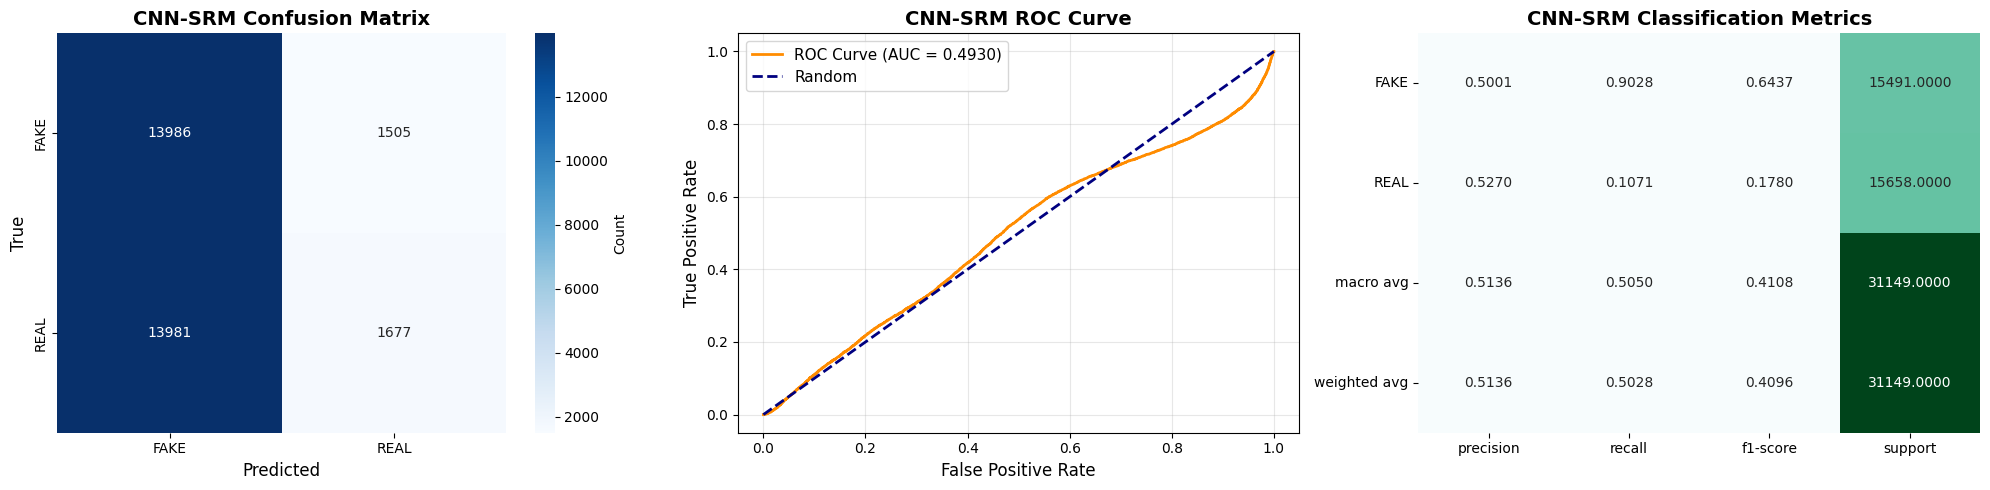


📋 CNN-SRM CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE     0.5001    0.9028    0.6437     15491
        REAL     0.5270    0.1071    0.1780     15658

    accuracy                         0.5028     31149
   macro avg     0.5136    0.5050    0.4108     31149
weighted avg     0.5136    0.5028    0.4096     31149


✅ CNN-SRM ROC AUC: 0.4930
✅ Visualizations complete!


In [43]:
# ============================================================================
# CNN-SRM Visualizations (Confusion Matrix + ROC + Metrics Table)
# מותאם למחברת שלך: cnn_srm + test_srm_dataset
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, roc_auc_score

# ============================================================================
# 1. Collect predictions from cnn_srm on test_srm_dataset
# ============================================================================

y_true = []
y_prob = []

for x_batch, y_batch in test_srm_dataset:
    preds = cnn_srm.predict(x_batch, verbose=0).flatten()
    y_true.extend(y_batch.numpy())
    y_prob.extend(preds)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred_binary = (y_prob > 0.5).astype(int)

print("✅ Predictions collected successfully")
print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)
print("First 10 probabilities:", y_prob[:10])

# ============================================================================
# 2. Compute metrics
# ============================================================================

cm = confusion_matrix(y_true, y_pred_binary)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

clf_report = classification_report(
    y_true,
    y_pred_binary,
    target_names=['FAKE', 'REAL'],
    output_dict=True
)

report_df = pd.DataFrame(clf_report).T
report_df = report_df.loc[
    ['FAKE', 'REAL', 'macro avg', 'weighted avg'],
    ['precision', 'recall', 'f1-score', 'support']
]

# ============================================================================
# 3. Plot: Confusion Matrix + ROC + Classification Table
# ============================================================================

plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ========== 1. Confusion Matrix ==========
ax1 = axes[0]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax1,
    xticklabels=['FAKE', 'REAL'],
    yticklabels=['FAKE', 'REAL'],
    cbar_kws={'label': 'Count'}
)

ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('CNN-SRM Confusion Matrix', fontsize=14, fontweight='bold')

# ========== 2. ROC Curve ==========
ax2 = axes[1]

ax2.plot(
    fpr, tpr,
    color='darkorange',
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)
ax2.plot(
    [0, 1], [0, 1],
    color='navy',
    linewidth=2,
    linestyle='--',
    label='Random'
)

ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('CNN-SRM ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# ========== 3. Classification Metrics Table ==========
ax3 = axes[2]

sns.heatmap(
    report_df,
    annot=True,
    cmap='BuGn',
    fmt='.4f',
    ax=ax3,
    cbar=False
)

ax3.set_title('CNN-SRM Classification Metrics', fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================================
# 4. Text report
# ============================================================================

print("\n" + "=" * 70)
print("📋 CNN-SRM CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred_binary, target_names=['FAKE', 'REAL'], digits=4))

print(f"\n✅ CNN-SRM ROC AUC: {roc_auc:.4f}")
print("✅ Visualizations complete!")

# EfficientNetB0 Model

In [9]:
import tensorflow as tf
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision, Recall

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Random rotation via crop+pad trick
    image = tf.keras.layers.RandomRotation(0.05)(image, training=True)

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

def preprocess_for_efficientnet(image, label):
    image = preprocess_input(image)
    return image, label

def build_rgb_dataset(image_paths, labels, batch_size=16, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.map(preprocess_for_efficientnet, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_rgb_ds = build_rgb_dataset(train_image_paths, train_labels, batch_size=BATCH_SIZE, training=True)
val_rgb_ds   = build_rgb_dataset(validation_image_paths, val_labels, batch_size=BATCH_SIZE, training=False)
test_rgb_ds  = build_rgb_dataset(test_image_paths, test_labels, batch_size=BATCH_SIZE, training=False)

print("✅ RGB datasets ready")
print("Train samples:", len(train_image_paths))
print("Val samples:", len(validation_image_paths))
print("Test samples:", len(test_image_paths))

I0000 00:00:1774017220.155244  369162 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6325 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-03-20 14:33:40.828893: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packag

✅ RGB datasets ready
Train samples: 241943
Val samples: 59670
Test samples: 31149


In [8]:
def build_efficientnet_b0(input_shape=(224, 224, 3), train_base=False):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = train_base

    inputs = Input(shape=input_shape, name="rgb_input")
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.30)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)
    outputs = Dense(1, activation="sigmoid", name="prob_fake")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_Deepfake")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            "accuracy",
            AUC(name="auc"),
            Precision(name="precision"),
            Recall(name="recall")
        ]
    )
    return model, base_model

eff_model, eff_base = build_efficientnet_b0(train_base=False)
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_fake (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes_arr = np.array(train_labels)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes_arr),
    y=classes_arr
)
srm_class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print("SRM class weights:", srm_class_weights)

Class weights: {0: np.float64(1.002914110429448), 1: np.float64(0.9971027752363526)}


In [44]:
SAVE_DIR = os.path.join(GDRIVE_PATH, "code/models/efficientnet_b0")
os.makedirs(SAVE_DIR, exist_ok=True)

stage1_path = os.path.join(SAVE_DIR, "efficientnetb0_stage1_best.keras")

callbacks_stage1 = [
    ModelCheckpoint(stage1_path, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_stage1 = eff_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=15,
    class_weight=srm_class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/8


2026-03-20 13:02:30.960041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.100114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.423537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.564504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:32.473686: E external/local_xla/xla/stream_

15119/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9674 - auc: 0.8253 - loss: 0.0842 - precision: 0.9798 - recall: 0.9690

2026-03-20 13:08:02.951961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.087878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.403305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.544230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:04.417643: E external/local_xla/xla/stream_

15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9674 - auc: 0.8254 - loss: 0.0842 - precision: 0.9798 - recall: 0.9690

2026-03-20 13:09:36.210712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.346413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.659650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.800166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:37.670853: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from None to 0.71139, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 450s 28ms/step - accuracy: 0.9612 - auc: 0.9930 - loss: 0.1007 - precision: 0.9698 - recall: 0.9521 - val_accuracy: 0.5097 - val_auc: 0.7114 - val_loss: 2.5002 - val_precision: 0.9476 - val_recall: 0.0194 - learning_rate: 1.0000e-04
Epoch 2/8
15121/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9663 - auc: 0.8264 - loss: 0.0934 - precision: 0.9815 - recall: 0.9669
Epoch 2: val_auc improved from 0.71139 to 0.75099, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras

Epoch 2: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras
15122/15122 ━━━━━━━━━━━━━━━

In [13]:
SAVE_DIR = os.path.join(GDRIVE_PATH, "code/models/efficientnet_b0")

stage1_path = os.path.join(SAVE_DIR, "efficientnetb0_stage1_best.keras")

# טוענים את הכי טוב משלב 1
eff_model = tf.keras.models.load_model(stage1_path)

# פותחים את ה-backbone
eff_base = eff_model.get_layer("efficientnetb0")
eff_base.trainable = True

# מקפיאים את השכבות הראשונות, פותחים רק את החלק העליון
fine_tune_at = int(len(eff_base.layers) * 0.7)

for layer in eff_base.layers[:fine_tune_at]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        AUC(name="auc"),
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

stage2_path = os.path.join(SAVE_DIR, "efficientnetb0_finetuned_best.keras")

callbacks_stage2 = [
    ModelCheckpoint(stage2_path, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history_stage2 = eff_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=15,
    class_weight=class_weights_arr,
    callbacks=callbacks_stage2
)

Epoch 1/10


2026-03-20 14:41:22.761929: I external/local_xla/xla/service/service.cc:163] XLA service 0x728068002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 14:41:22.761961: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-20 14:41:23.502511: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 14:41:26.703064: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-20 14:41:34.551609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:41:34.691918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time h

15120/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9405 - auc: 0.8175 - loss: 0.1541 - precision: 0.9755 - recall: 0.9420

2026-03-20 14:49:31.203423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.339575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.653497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.794241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:32.681030: E external/local_xla/xla/stream_

15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9405 - auc: 0.8175 - loss: 0.1541 - precision: 0.9755 - recall: 0.9420

2026-03-20 14:51:12.361309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.496960: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.813532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.954517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:13.854932: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from None to 0.76417, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 614s 38ms/step - accuracy: 0.9608 - auc: 0.9921 - loss: 0.1074 - precision: 0.9678 - recall: 0.9534 - val_accuracy: 0.5534 - val_auc: 0.7642 - val_loss: 2.3259 - val_precision: 0.9867 - val_recall: 0.1074 - learning_rate: 1.0000e-05
Epoch 2/10
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9601 - auc: 0.8250 - loss: 0.1174 - precision: 0.9827 - recall: 0.9624
Epoch 2: val_auc improved from 0.76417 to 0.77482, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras
15122/15122 ━━

In [14]:
best_eff_model = tf.keras.models.load_model(stage2_path)

test_results = best_eff_model.evaluate(test_rgb_ds, verbose=1)
print("\n✅ EfficientNetB0 Test Results:")
for name, value in zip(best_eff_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

1946/1947 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2939 - auc: 0.5129 - loss: 4.3495 - precision: 0.9920 - recall: 0.0593

2026-03-20 16:59:49.138345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.277292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.598112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.738893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:50.607157: E external/local_xla/xla/stream_

1947/1947 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - accuracy: 0.5811 - auc: 0.7727 - loss: 2.3924 - precision: 0.9494 - recall: 0.1761

✅ EfficientNetB0 Test Results:
loss: 2.3924
compile_metrics: 0.5811


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

y_true = []
y_prob = []

for x_batch, y_batch in test_rgb_ds:
    probs = best_eff_model.predict(x_batch, verbose=0).flatten()
    y_true.extend(y_batch.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.2).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("\nROC AUC:")
print(roc_auc_score(y_true, y_prob))

Confusion Matrix:
[[15223   268]
 [11788  3870]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5636    0.9827    0.7163     15491
           1     0.9352    0.2472    0.3910     15658

    accuracy                         0.6130     31149
   macro avg     0.7494    0.6149    0.5537     31149
weighted avg     0.7504    0.6130    0.5528     31149


ROC AUC:
0.8796754503471947


2026-03-20 17:14:24.764640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
